<a href="https://colab.research.google.com/github/Sadith14/ALGORITMOS-DE-ENJAMBRE-EN-EL-APRENDIZAJE-M-QUINA/blob/main/swarm_clustering_mushrooms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering con Algoritmos de Enjambre
## Dataset: Mushrooms (UCI)

**Dos enfoques:**
- **PSO (Particle Swarm Optimization)**: clustering con k=2 (venenoso vs comestible)
- **ABC (Artificial Bee Colony)**: clustering con k óptimo buscado automáticamente

Cada algoritmo muestra el ciclo completo:
1. Representación de la partícula
2. Inicialización del enjambre
3. Función de aptitud
4. Comportamiento de la partícula
5. Evolución
6. Finalización

In [ ]:
# ============================================================
# CELDA 1: Instalación e importaciones
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [ ]:
# ============================================================
# CELDA 2: Carga y preprocesamiento del dataset
# ============================================================
from google.colab import drive
drive.mount('/content/drive')
ruta = '/content/drive/MyDrive/noveno/mushrooms.csv'
df = pd.read_csv(ruta)

print('Shape:', df.shape)
print('Columnas:', df.columns.tolist())
print()
print('Distribución de clases (class):')
print(df['class'].value_counts())
print('  p = poisonous (venenoso), e = edible (comestible)')

Mounted at /content/drive
Shape: (8124, 23)
Columnas: ['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

Distribución de clases (class):
class
e    4208
p    3916
Name: count, dtype: int64
  p = poisonous (venenoso), e = edible (comestible)


In [ ]:
# ============================================================
# CELDA 3: Preprocesamiento mejorado
# ============================================================

# Etiquetas reales
le_class = LabelEncoder()
y_true = le_class.fit_transform(df['class'])  # e=0, p=1

# Encoding por frecuencia (mejor que ordinal para datos categóricos)
df_encoded = df.copy()
for col in df_encoded.columns:
    freq = df_encoded[col].value_counts(normalize=True)
    df_encoded[col] = df_encoded[col].map(freq)

X = df_encoded.drop('class', axis=1).values.astype(float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Solo 2 componentes — suficiente y espacio de búsqueda mínimo
pca_full = PCA(n_components=5, random_state=42)
X_pca = pca_full.fit_transform(X_scaled)
X_vis = X_pca.copy()  # mismas dimensiones para visualizar

# Muestra
from sklearn.utils import resample
idx_sample = resample(np.arange(len(X_pca)), n_samples=1500, random_state=42, replace=False)
X_pca_sample = X_pca[idx_sample]
y_sample = y_true[idx_sample]

print(f'Datos para clustering: {X_pca_sample.shape}')
print(f'Varianza explicada (2 PCs): {pca_full.explained_variance_ratio_.sum():.3f}')
print(f'\nVerificación — separabilidad visual:')
for c, nombre in enumerate(['edible', 'poisonous']):
    pts = X_pca[y_true == c]
    print(f'  {nombre}: centroide=({pts[:,0].mean():.3f}, {pts[:,1].mean():.3f})')

Datos para clustering: (1500, 5)
Varianza explicada (2 PCs): 0.631

Verificación — separabilidad visual:
  edible: centroide=(-0.513, 1.185)
  poisonous: centroide=(0.551, -1.273)


---
# PARTE 1: PSO-Clustering (k=2)

## Ciclo del algoritmo PSO

| Elemento | Descripción |
|---|---|
| **Representación de partícula** | Vector de k×d valores reales = k centroides concatenados |
| **Inicialización** | Centroides aleatorios dentro del rango de los datos |
| **Función de aptitud** | Inercia total (suma de distancias²punto→centroide más cercano) |
| **Comportamiento** | Cada partícula se mueve por inercia + atracción a pbest y gbest |
| **Evolución** | Actualización de velocidad y posición en cada iteración |
| **Finalización** | Número máximo de iteraciones o convergencia de gbest |

In [ ]:
# ============================================================
# CELDA 4: Implementación PSO para Clustering
# ============================================================

class PSOClustering:
    """
    PSO para clustering.
    Cada partícula representa k centroides concatenados.
    La función de aptitud es la inercia (menor = mejor).
    """

    def __init__(self, k, n_particles=30, max_iter=100,
                 w=0.7, c1=1.5, c2=1.5, random_state=42):
        """
        Parámetros:
        -----------
        k           : número de clusters
        n_particles : tamaño del enjambre
        max_iter    : iteraciones máximas
        w           : peso de inercia (controla la exploración)
        c1          : coeficiente cognitivo (atracción a pbest)
        c2          : coeficiente social (atracción a gbest)
        """
        self.k = k
        self.n_particles = n_particles
        self.max_iter = max_iter
        self.w = w
        self.c1 = c1
        self.c2 = c2
        self.rng = np.random.RandomState(random_state)

    # ------------------------------------------------------------------
    # FUNCIÓN DE APTITUD
    # ------------------------------------------------------------------
    def _fitness(self, position, X):
        """
        Calcula la inercia total (intra-cluster sum of squares).
        Menor valor = clusters más compactos = mejor solución.
        """
        d = X.shape[1]
        centroids = position.reshape(self.k, d)   # decodificar partícula

        # Asignar cada punto al centroide más cercano
        dists = np.linalg.norm(
            X[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2
        )  # shape: (n, k)
        labels = np.argmin(dists, axis=1)

        # Verificar que todos los clusters tengan al menos 1 punto
        if len(np.unique(labels)) < self.k:
            return np.inf   # penalización

        # Calcular inercia
        inertia = sum(
            np.sum((X[labels == i] - centroids[i]) ** 2)
            for i in range(self.k)
        )
        return inertia

    # ------------------------------------------------------------------
    # ENTRENAMIENTO
    # ------------------------------------------------------------------
    def fit(self, X):
        n, d = X.shape
        dim = self.k * d   # dimensión del espacio de búsqueda

        x_min, x_max = X.min(axis=0), X.max(axis=0)
        v_max = (x_max - x_min) * 0.1   # velocidad máxima

        # ── INICIALIZACIÓN DEL ENJAMBRE ────────────────────────────────
        # Inicialización k-means++ : primer centroide aleatorio,
        # los siguientes se eligen con probabilidad proporcional a distancia²
        positions = np.zeros((self.n_particles, dim))
        for p in range(self.n_particles):
            cents = []
            cents.append(X[self.rng.randint(0, len(X))])
            for _ in range(1, self.k):
                dists_sq = np.array([
                    min(np.sum((x - c)**2) for c in cents) for x in X
                ])
                probs = dists_sq / dists_sq.sum()
                idx = self.rng.choice(len(X), p=probs)
                cents.append(X[idx])
            positions[p] = np.concatenate(cents)

        v_max_tiled = np.tile(v_max, self.k)  # shape (dim,) para que coincida
        velocities = self.rng.uniform(
            -v_max_tiled, v_max_tiled,
            size=(self.n_particles, dim)
        )
        # Mejor posición personal (pbest) y global (gbest)
        pbest_pos = positions.copy()
        pbest_fit = np.array([self._fitness(p, X) for p in positions])

        gbest_idx = np.argmin(pbest_fit)
        gbest_pos = pbest_pos[gbest_idx].copy()
        gbest_fit = pbest_fit[gbest_idx]

        history = [gbest_fit]

        # ── EVOLUCIÓN ─────────────────────────────────────────────────
        for iteration in range(self.max_iter):
            r1 = self.rng.rand(self.n_particles, dim)
            r2 = self.rng.rand(self.n_particles, dim)

            # COMPORTAMIENTO DE LA PARTÍCULA:
            # v(t+1) = w*v(t) + c1*r1*(pbest - x) + c2*r2*(gbest - x)
            # w decrece de 0.9 a 0.4 conforme avanzan las iteraciones
            w_current = 0.9 - (0.5 * iteration / self.max_iter)
            velocities = (
                w_current * velocities
                + self.c1 * r1 * (pbest_pos - positions)
                + self.c2 * r2 * (gbest_pos - positions)
            )
            velocities = (
                self.w * velocities
                + self.c1 * r1 * (pbest_pos - positions)
                + self.c2 * r2 * (gbest_pos - positions)
            )

            # Limitar velocidad
            velocities = np.clip(
                velocities,
                np.tile(-v_max, self.k),
                np.tile(v_max, self.k)
            )

            # Actualizar posición
            positions = positions + velocities

            # Limitar posición al espacio válido
            positions = np.clip(
                positions,
                np.tile(x_min, self.k),
                np.tile(x_max, self.k)
            )

            # Evaluar aptitud
            fitness_vals = np.array([self._fitness(p, X) for p in positions])

            # Actualizar pbest
            improved = fitness_vals < pbest_fit
            pbest_pos[improved] = positions[improved].copy()
            pbest_fit[improved] = fitness_vals[improved]

            # Actualizar gbest
            best_idx = np.argmin(pbest_fit)
            if pbest_fit[best_idx] < gbest_fit:
                gbest_pos = pbest_pos[best_idx].copy()
                gbest_fit = pbest_fit[best_idx]

            history.append(gbest_fit)

            if (iteration + 1) % 20 == 0:
                print(f'  Iter {iteration+1:3d}/{self.max_iter} | gbest inercia = {gbest_fit:.4f}')

        # ── FINALIZACIÓN ──────────────────────────────────────────────
        # Decodificar mejor solución encontrada
        best_centroids = gbest_pos.reshape(self.k, d)
        dists = np.linalg.norm(
            X[:, np.newaxis, :] - best_centroids[np.newaxis, :, :], axis=2
        )
        self.labels_ = np.argmin(dists, axis=1)
        self.cluster_centers_ = best_centroids
        self.inertia_ = gbest_fit
        self.history_ = history
        return self

print('Clase PSOClustering definida.')

Clase PSOClustering definida.


In [ ]:
# ============================================================
# CELDA 5: Ejecutar PSO-Clustering con k=2
# ============================================================
print('=== PSO Clustering (k=2) ===')
print('Inicializando enjambre...')

print('=== PSO Clustering (k=2) ===')
pso = PSOClustering(
    k=2,
    n_particles=40,
    max_iter=200,   # más iteraciones
    w=0.5,          # menos inercia = más explotación
    c1=2.0,
    c2=2.0,
    random_state=42
)
pso.fit(X_pca_sample)   # usar muestra

ari_pso = adjusted_rand_score(y_sample, pso.labels_)
sil_pso = silhouette_score(X_pca_sample, pso.labels_)

print(f'\nResultados PSO (k=2):')
print(f'  Inercia final:          {pso.inertia_:.4f}')
print(f'  Adjusted Rand Index:    {ari_pso:.4f}')
print(f'  Silhouette Score:       {sil_pso:.4f}')

for c in range(2):
    mask = pso.labels_ == c
    n_edible = (y_sample[mask] == 0).sum()
    n_poison = (y_sample[mask] == 1).sum()
    print(f'  Cluster {c}: {mask.sum():5d} puntos | edible={n_edible} | poisonous={n_poison}')

=== PSO Clustering (k=2) ===
Inicializando enjambre...
=== PSO Clustering (k=2) ===
  Iter  20/200 | gbest inercia = 15931.4330
  Iter  40/200 | gbest inercia = 15746.5917
  Iter  60/200 | gbest inercia = 15713.4555
  Iter  80/200 | gbest inercia = 15713.4555
  Iter 100/200 | gbest inercia = 15713.4555
  Iter 120/200 | gbest inercia = 15713.4555
  Iter 140/200 | gbest inercia = 15713.4555
  Iter 160/200 | gbest inercia = 15713.4555
  Iter 180/200 | gbest inercia = 15666.4203
  Iter 200/200 | gbest inercia = 15666.4203

Resultados PSO (k=2):
  Inercia final:          15666.4203
  Adjusted Rand Index:    0.5854
  Silhouette Score:       0.2706
  Cluster 0:   912 puntos | edible=759 | poisonous=153
  Cluster 1:   588 puntos | edible=23 | poisonous=565


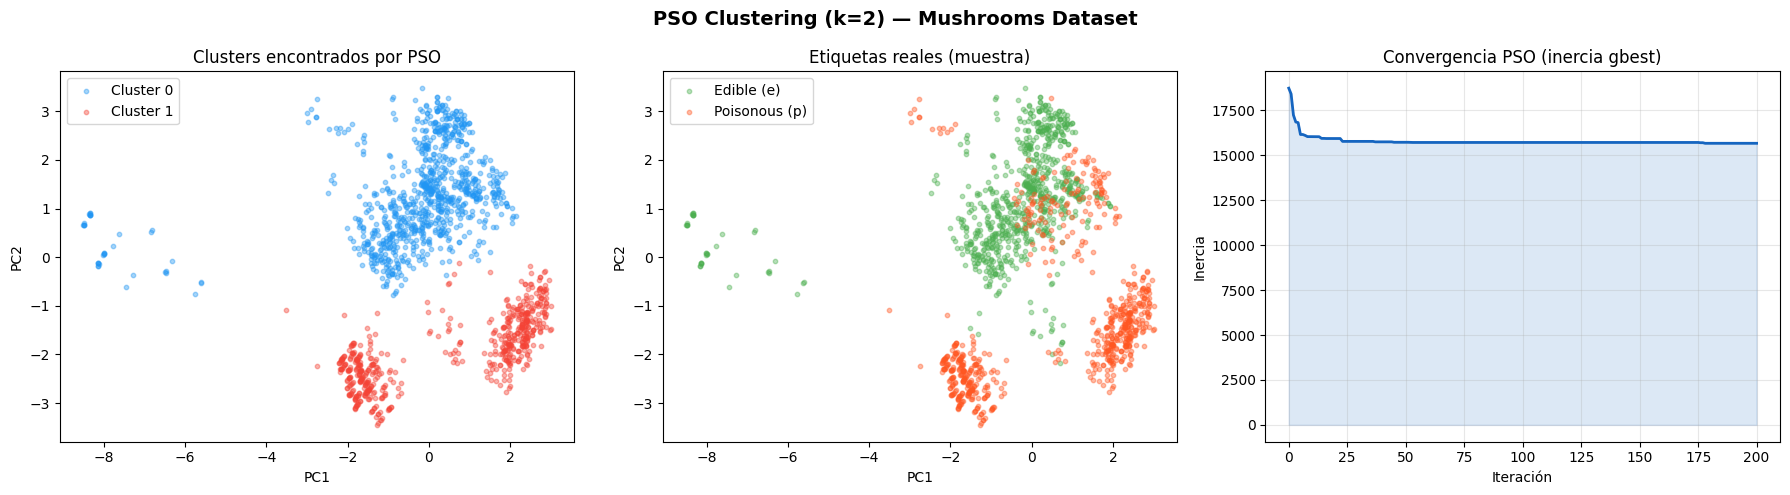

Figura guardada como pso_clustering.png


In [ ]:
import matplotlib.pyplot as plt

# ============================================================
# CELDA 6: Visualización PSO
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('PSO Clustering (k=2) — Mushrooms Dataset', fontsize=14, fontweight='bold')

colors_pso = ['#2196F3', '#F44336']
labels_pso = ['Cluster 0', 'Cluster 1']

# --- Plot 1: Clusters encontrados por PSO ---
ax = axes[0]
for c in range(2):
    mask = pso.labels_ == c
    ax.scatter(X_pca_sample[mask, 0], X_pca_sample[mask, 1],
               c=colors_pso[c], label=labels_pso[c],
               alpha=0.4, s=10)
ax.set_title('Clusters encontrados por PSO')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()

# --- Plot 2: Etiquetas reales ---
ax = axes[1]
colors_real = ['#4CAF50', '#FF5722']
real_labels = ['Edible (e)', 'Poisonous (p)']
for c in range(2):
    mask = y_sample == c
    ax.scatter(X_pca_sample[mask, 0], X_pca_sample[mask, 1],
               c=colors_real[c], label=real_labels[c],
               alpha=0.4, s=10)
ax.set_title('Etiquetas reales (muestra)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()

# --- Plot 3: Convergencia PSO ---
ax = axes[2]
ax.plot(pso.history_, color='#1565C0', linewidth=2)
ax.fill_between(range(len(pso.history_)), pso.history_,
                alpha=0.15, color='#1565C0')
ax.set_title('Convergencia PSO (inercia gbest)')
ax.set_xlabel('Iteración')
ax.set_ylabel('Inercia')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pso_clustering.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada como pso_clustering.png')

---
# PARTE 2: ABC-Clustering (k óptimo automático)

## Ciclo del algoritmo ABC

| Elemento | Descripción |
|---|---|
| **Representación de partícula** | Fuente de alimento = vector [k, centroides_k×d] donde k también es variable |
| **Inicialización** | Fuentes con k ∈ {2,3,4,5} y centroides aleatorios |
| **Función de aptitud** | Índice de Davies-Bouldin (menor = mejor; penaliza clusters muy similares) |
| **Comportamiento** | Abejas empleadas exploran cerca de su fuente; observadoras eligen por ruleta; exploradoras reinician fuentes estancadas |
| **Evolución** | Ciclos de employed → onlooker → scout |
| **Finalización** | Número máximo de ciclos |

In [ ]:
# ============================================================
# CELDA 7: Implementación ABC para Clustering con k variable
# ============================================================
from sklearn.metrics import davies_bouldin_score

class ABCClustering:
    """
    ABC para clustering con k variable.
    Cada fuente de alimento es una solución completa:
      - k (número de clusters)
      - k centroides de dimensión d
    La función de aptitud es el índice Davies-Bouldin (menor = mejor).
    """

    def __init__(self, k_min=2, k_max=6, n_bees=20, max_cycles=80,
                 limit=10, random_state=42):
        """
        Parámetros:
        -----------
        k_min, k_max : rango de k a explorar
        n_bees       : número de fuentes (= abejas empleadas = abejas observadoras)
        max_cycles   : ciclos máximos
        limit        : intentos sin mejora antes de abandonar una fuente (abeja exploradora)
        """
        self.k_min = k_min
        self.k_max = k_max
        self.n_bees = n_bees
        self.max_cycles = max_cycles
        self.limit = limit
        self.rng = np.random.RandomState(random_state)

    # ------------------------------------------------------------------
    # FUNCIÓN DE APTITUD
    # ------------------------------------------------------------------
    def _fitness(self, centroids, X):
        k = len(centroids)
        dists = np.linalg.norm(
            X[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2
        )
        labels = np.argmin(dists, axis=1)

        if len(np.unique(labels)) < k:
            return np.inf, labels

        # Penalizar clusters muy pequeños (menos del 5% del total)
        min_size = len(X) * 0.05
        if any((labels == c).sum() < min_size for c in range(k)):
            return np.inf, labels

        db = davies_bouldin_score(X, labels)
        return db, labels
    # ------------------------------------------------------------------
    # CREAR UNA FUENTE NUEVA ALEATORIA
    # ------------------------------------------------------------------
    def _new_source(self, X, k=None):
        if k is None:
            k = self.rng.randint(self.k_min, self.k_max + 1)
        # Inicialización k-means++ igual que PSO
        cents = []
        cents.append(X[self.rng.randint(0, len(X))])
        for _ in range(1, k):
            dists_sq = np.array([
                min(np.sum((x - c)**2) for c in cents) for x in X
            ])
            probs = dists_sq / dists_sq.sum()
            idx = self.rng.choice(len(X), p=probs)
            cents.append(X[idx])
        centroids = np.array(cents)
        return k, centroids

    # ------------------------------------------------------------------
    # PERTURBACIÓN DE UNA FUENTE (abeja empleada/observadora)
    # ------------------------------------------------------------------
    def _perturb(self, centroids, X, partner_centroids):
        """
        Modifica aleatoriamente uno de los centroides.
        Si partner tiene el mismo k, usa la fórmula ABC estándar;
        si no, aplica un desplazamiento gaussiano.
        """
        new_c = centroids.copy()
        i = self.rng.randint(0, len(new_c))  # centroide a modificar
        phi = self.rng.uniform(-1, 1, new_c.shape[1])

        if len(partner_centroids) == len(centroids):
            j = self.rng.randint(0, len(new_c))
            new_c[i] = new_c[i] + phi * (new_c[i] - partner_centroids[j])
        else:
            new_c[i] = new_c[i] + phi * np.std(X, axis=0) * 0.3

        # Limitar al rango de los datos
        new_c = np.clip(new_c, X.min(axis=0), X.max(axis=0))
        return new_c

    # ------------------------------------------------------------------
    # ENTRENAMIENTO
    # ------------------------------------------------------------------
    def fit(self, X):

        # ── INICIALIZACIÓN DEL ENJAMBRE ────────────────────────────────
        sources_k = []
        sources_c = []
        sources_fit = []
        sources_labels = []
        counters = np.zeros(self.n_bees, dtype=int)

        for _ in range(self.n_bees):
            k, c = self._new_source(X)
            f, lbl = self._fitness(c, X)
            sources_k.append(k)
            sources_c.append(c)
            sources_fit.append(f)
            sources_labels.append(lbl)

        best_idx = int(np.argmin(sources_fit))
        best_fit = sources_fit[best_idx]
        best_k   = sources_k[best_idx]
        best_c   = sources_c[best_idx].copy()
        best_lbl = sources_labels[best_idx].copy()
        history  = [best_fit]
        k_history = [best_k]

        # ── EVOLUCIÓN ─────────────────────────────────────────────────
        for cycle in range(self.max_cycles):

            # FASE 1: Abejas empleadas
            for i in range(self.n_bees):
                j = self.rng.choice([x for x in range(self.n_bees) if x != i])
                new_c = self._perturb(sources_c[i], X, sources_c[j])
                new_f, new_lbl = self._fitness(new_c, X)

                if new_f < sources_fit[i]:
                    sources_c[i] = new_c
                    sources_fit[i] = new_f
                    sources_labels[i] = new_lbl
                    counters[i] = 0
                else:
                    counters[i] += 1

            # FASE 2: Abejas observadoras (selección por ruleta)
            fit_arr = np.array(sources_fit)
            # Convertir fitness (menor=mejor) a probabilidad (mayor=más probable)
            inv_fit = 1.0 / (1.0 + fit_arr)
            probs = inv_fit / inv_fit.sum()

            for _ in range(self.n_bees):
                i = self.rng.choice(self.n_bees, p=probs)
                j = self.rng.choice([x for x in range(self.n_bees) if x != i])
                new_c = self._perturb(sources_c[i], X, sources_c[j])
                new_f, new_lbl = self._fitness(new_c, X)

                if new_f < sources_fit[i]:
                    sources_c[i] = new_c
                    sources_fit[i] = new_f
                    sources_labels[i] = new_lbl
                    counters[i] = 0
                else:
                    counters[i] += 1

            # FASE 3: Abejas exploradoras (reiniciar fuentes estancadas)
            for i in range(self.n_bees):
                if counters[i] >= self.limit:
                    k, c = self._new_source(X)
                    f, lbl = self._fitness(c, X)
                    sources_k[i] = k
                    sources_c[i] = c
                    sources_fit[i] = f
                    sources_labels[i] = lbl
                    counters[i] = 0

            # Actualizar el mejor global
            current_best = int(np.argmin(sources_fit))
            if sources_fit[current_best] < best_fit:
                best_fit = sources_fit[current_best]
                best_k   = sources_k[current_best]
                best_c   = sources_c[current_best].copy()
                best_lbl = sources_labels[current_best].copy()

            history.append(best_fit)
            k_history.append(best_k)

            if (cycle + 1) % 20 == 0:
                print(f'  Ciclo {cycle+1:3d}/{self.max_cycles} | DB={best_fit:.4f} | k óptimo={best_k}')

        # ── FINALIZACIÓN ──────────────────────────────────────────────
        self.labels_ = best_lbl
        self.cluster_centers_ = best_c
        self.k_optimal_ = best_k
        self.db_score_ = best_fit
        self.history_ = history
        self.k_history_ = k_history
        return self

print('Clase ABCClustering definida.')

Clase ABCClustering definida.


In [ ]:
# ============================================================
# CELDA 8: Ejecutar ABC-Clustering
# ============================================================
print('=== ABC Clustering (k óptimo automático) ===')
print('Inicializando enjambre...')

abc = ABCClustering(
    k_min=2,
    k_max=5,
    n_bees=20,
    max_cycles=120,
    limit=6,          # abandona fuentes estancadas más rápido → más exploración
    random_state=42
)
abc.fit(X_pca_sample)

# Métricas
ari_abc = adjusted_rand_score(y_sample, abc.labels_)
sil_abc = silhouette_score(X_pca_sample, abc.labels_)

print(f'\nResultados ABC:')
print(f'  k óptimo encontrado:    {abc.k_optimal_}')
print(f'  Davies-Bouldin Score:   {abc.db_score_:.4f}  (menor = mejor)')
print(f'  Adjusted Rand Index:    {ari_abc:.4f}  (1.0 = perfecto)')
print(f'  Silhouette Score:       {sil_abc:.4f}  (1.0 = perfecto)')

print(f'\nDistribución clusters ABC:')
for c in range(abc.k_optimal_):
    mask = abc.labels_ == c
    n_edible = (y_sample[mask] == 0).sum()
    n_poison = (y_sample[mask] == 1).sum()
    print(f'  Cluster {c}: {mask.sum():5d} puntos | edible={n_edible} | poisonous={n_poison}')

=== ABC Clustering (k óptimo automático) ===
Inicializando enjambre...
  Ciclo  20/120 | DB=0.7350 | k óptimo=5
  Ciclo  40/120 | DB=0.7350 | k óptimo=5
  Ciclo  60/120 | DB=0.7129 | k óptimo=5
  Ciclo  80/120 | DB=0.7129 | k óptimo=5
  Ciclo 100/120 | DB=0.7129 | k óptimo=5
  Ciclo 120/120 | DB=0.7129 | k óptimo=5

Resultados ABC:
  k óptimo encontrado:    5
  Davies-Bouldin Score:   0.7129  (menor = mejor)
  Adjusted Rand Index:    0.2408  (1.0 = perfecto)
  Silhouette Score:       0.5203  (1.0 = perfecto)

Distribución clusters ABC:
  Cluster 0:   211 puntos | edible=199 | poisonous=12
  Cluster 1:   225 puntos | edible=165 | poisonous=60
  Cluster 2:   389 puntos | edible=342 | poisonous=47
  Cluster 3:   292 puntos | edible=35 | poisonous=257
  Cluster 4:   383 puntos | edible=41 | poisonous=342


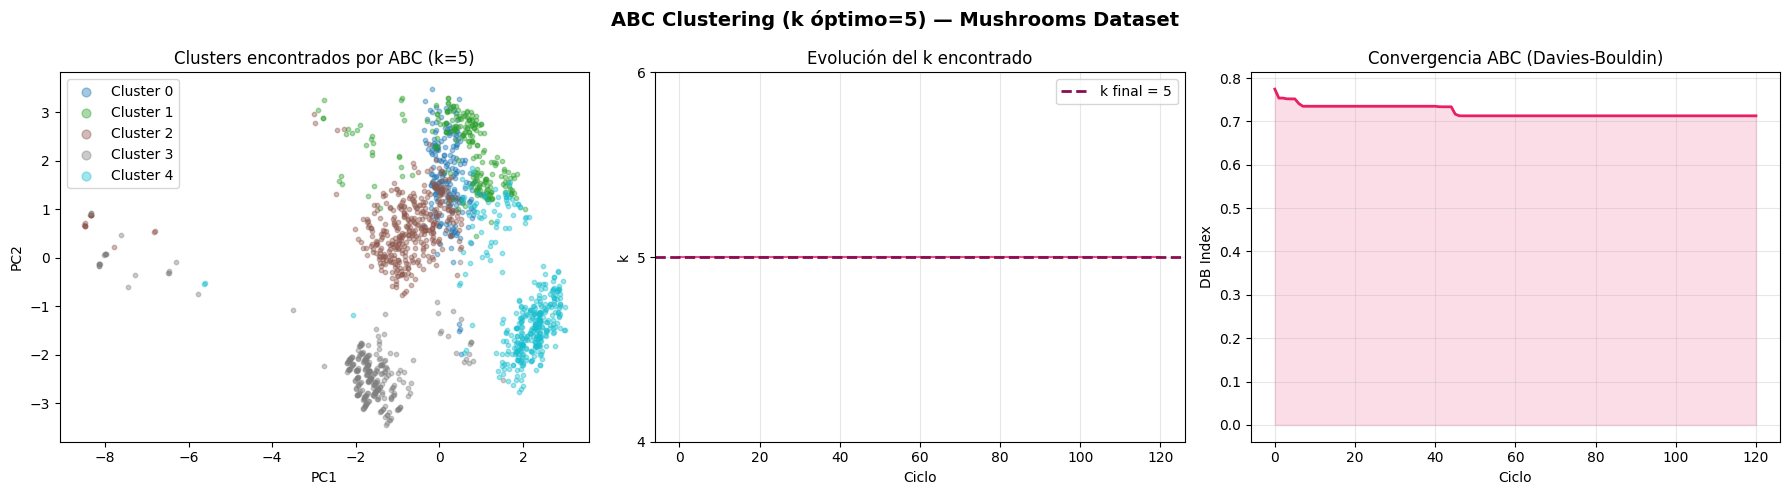

Figura guardada como abc_clustering.png


In [ ]:
# ============================================================
# CELDA 9: Visualización ABC
# ============================================================
k_opt = abc.k_optimal_
palette = cm.get_cmap('tab10', k_opt)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'ABC Clustering (k óptimo={k_opt}) — Mushrooms Dataset',
             fontsize=14, fontweight='bold')

# --- Plot 1: Clusters ABC ---
ax = axes[0]
for c in range(k_opt):
    mask = abc.labels_ == c
    ax.scatter(X_pca_sample[mask, 0], X_pca_sample[mask, 1],
               color=palette(c), label=f'Cluster {c}',
               alpha=0.4, s=10)
ax.set_title(f'Clusters encontrados por ABC (k={k_opt})')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(markerscale=2)

# --- Plot 2: Evolución del k óptimo ---
ax = axes[1]
ax.plot(abc.k_history_, color='#E91E63', linewidth=1.5, alpha=0.8)
ax.axhline(k_opt, color='#880E4F', linestyle='--', linewidth=2,
           label=f'k final = {k_opt}')
ax.set_title('Evolución del k encontrado')
ax.set_xlabel('Ciclo')
ax.set_ylabel('k')
ax.set_yticks(range(abc.k_history_[0] - 1 if abc.k_history_ else 2,
                    max(abc.k_history_) + 2))
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 3: Convergencia Davies-Bouldin ---
ax = axes[2]
ax.plot(abc.history_, color='#E91E63', linewidth=2)
ax.fill_between(range(len(abc.history_)), abc.history_,
                alpha=0.15, color='#E91E63')
ax.set_title('Convergencia ABC (Davies-Bouldin)')
ax.set_xlabel('Ciclo')
ax.set_ylabel('DB Index')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('abc_clustering.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada como abc_clustering.png')

In [ ]:
# ============================================================
# CELDA 10: Comparación final PSO vs ABC
# ============================================================
print('=' * 55)
print('COMPARACIÓN FINAL: PSO vs ABC')
print('=' * 55)
print(f'{'Métrica':<30} {'PSO (k=2)':>10} {'ABC (k=auto)':>12}')
print('-' * 55)
print(f'{'k usado':<30} {'2':>10} {abc.k_optimal_:>12}')
print(f'{'Adjusted Rand Index':<30} {ari_pso:>10.4f} {ari_abc:>12.4f}')
print(f'{'Silhouette Score':<30} {sil_pso:>10.4f} {sil_abc:>12.4f}')
print('=' * 55)
print()
print('Notas:')
print('  - ARI cercano a 1.0 indica que el clustering coincide con las etiquetas reales.')
print('  - Silhouette cercano a 1.0 indica clusters bien separados.')
print('  - PSO minimiza inercia (compacidad); ABC minimiza Davies-Bouldin (separación).')

COMPARACIÓN FINAL: PSO vs ABC
Métrica                         PSO (k=2) ABC (k=auto)
-------------------------------------------------------
k usado                                 2            5
Adjusted Rand Index                0.5854       0.2408
Silhouette Score                   0.2706       0.5203

Notas:
  - ARI cercano a 1.0 indica que el clustering coincide con las etiquetas reales.
  - Silhouette cercano a 1.0 indica clusters bien separados.
  - PSO minimiza inercia (compacidad); ABC minimiza Davies-Bouldin (separación).


In [ ]:
# ============================================================
# GWO Clustering (Grey Wolf Optimizer)
# Mirjalili et al., 2014
# ============================================================
class GWOClustering:
    """
    GWO para clustering con k fijo.
    Jerarquía: alfa (mejor) > beta (2do) > delta (3ro) > omega (resto).
    Cada lobo representa k centroides concatenados.
    Función de aptitud: inercia (igual que PSO para comparar directo).
    """

    def __init__(self, k, n_wolves=30, max_iter=200, random_state=42):
        self.k = k
        self.n_wolves = n_wolves
        self.max_iter = max_iter
        self.rng = np.random.RandomState(random_state)

    def _fitness(self, position, X):
        d = X.shape[1]
        centroids = position.reshape(self.k, d)
        dists = np.linalg.norm(
            X[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2
        )
        labels = np.argmin(dists, axis=1)
        if len(np.unique(labels)) < self.k:
            return np.inf
        return sum(
            np.sum((X[labels == i] - centroids[i]) ** 2)
            for i in range(self.k)
        )

    def fit(self, X):
        n, d = X.shape
        dim = self.k * d
        x_min, x_max = X.min(axis=0), X.max(axis=0)

        # ── INICIALIZACIÓN con k-means++ ──────────────────────────────
        positions = np.zeros((self.n_wolves, dim))
        for w in range(self.n_wolves):
            cents = [X[self.rng.randint(0, n)]]
            for _ in range(1, self.k):
                dists_sq = np.array([
                    min(np.sum((x - c)**2) for c in cents) for x in X
                ])
                probs = dists_sq / dists_sq.sum()
                cents.append(X[self.rng.choice(n, p=probs)])
            positions[w] = np.concatenate(cents)

        fitness_vals = np.array([self._fitness(p, X) for p in positions])

        # Identificar alfa, beta, delta
        sorted_idx = np.argsort(fitness_vals)
        alpha_pos = positions[sorted_idx[0]].copy()
        alpha_fit = fitness_vals[sorted_idx[0]]
        beta_pos  = positions[sorted_idx[1]].copy()
        delta_pos = positions[sorted_idx[2]].copy()

        history = [alpha_fit]

        # ── EVOLUCIÓN ─────────────────────────────────────────────────
        for iteration in range(self.max_iter):
            # a decrece linealmente de 2 a 0
            # a decrece más lento al inicio para mantener exploración
            a = 2.0 * (1 - (iteration / self.max_iter) ** 0.5)

            for i in range(self.n_wolves):
                # COMPORTAMIENTO: cada lobo se mueve hacia alfa, beta y delta
                r1, r2 = self.rng.rand(dim), self.rng.rand(dim)
                A1 = 2 * a * r1 - a
                C1 = 2 * r2
                X1 = alpha_pos - A1 * abs(C1 * alpha_pos - positions[i])

                r1, r2 = self.rng.rand(dim), self.rng.rand(dim)
                A2 = 2 * a * r1 - a
                C2 = 2 * r2
                X2 = beta_pos - A2 * abs(C2 * beta_pos - positions[i])

                r1, r2 = self.rng.rand(dim), self.rng.rand(dim)
                A3 = 2 * a * r1 - a
                C3 = 2 * r2
                X3 = delta_pos - A3 * abs(C3 * delta_pos - positions[i])

                # Nueva posición = promedio de las tres atracciones
                positions[i] = (X1 + X2 + X3) / 3.0
                positions[i] = np.clip(
                    positions[i],
                    np.tile(x_min, self.k),
                    np.tile(x_max, self.k)
                )
            # Mutación: 20% de los lobos omega se reinician con k-means++
            # para mantener diversidad y evitar convergencia prematura
            n_mutate = max(1, int(0.2 * self.n_wolves))
            omega_idx = sorted_idx[3:]  # todos menos alfa, beta, delta
            mutate_idx = self.rng.choice(omega_idx, n_mutate, replace=False)
            for mi in mutate_idx:
                cents = [X[self.rng.randint(0, n)]]
                for _ in range(1, self.k):
                    dists_sq = np.array([
                        min(np.sum((x - c)**2) for c in cents) for x in X
                    ])
                    probs = dists_sq / dists_sq.sum()
                    cents.append(X[self.rng.choice(n, p=probs)])
                positions[mi] = np.concatenate(cents)

            # Actualizar jerarquía
            fitness_vals = np.array([self._fitness(p, X) for p in positions])
            sorted_idx = np.argsort(fitness_vals)

            if fitness_vals[sorted_idx[0]] < alpha_fit:
                alpha_fit = fitness_vals[sorted_idx[0]]
                alpha_pos = positions[sorted_idx[0]].copy()
            beta_pos  = positions[sorted_idx[1]].copy()
            delta_pos = positions[sorted_idx[2]].copy()

            history.append(alpha_fit)

            if (iteration + 1) % 40 == 0:
                print(f'  Iter {iteration+1:3d}/{self.max_iter} | alfa inercia = {alpha_fit:.4f}')

        # ── FINALIZACIÓN ──────────────────────────────────────────────
        best_centroids = alpha_pos.reshape(self.k, d)
        dists = np.linalg.norm(
            X[:, np.newaxis, :] - best_centroids[np.newaxis, :, :], axis=2
        )
        self.labels_ = np.argmin(dists, axis=1)
        self.cluster_centers_ = best_centroids
        self.inertia_ = alpha_fit
        self.history_ = history
        return self

print('Clase GWOClustering definida.')

Clase GWOClustering definida.


=== GWO Clustering (k=2) ===
  Iter  40/200 | alfa inercia = 15465.1320
  Iter  80/200 | alfa inercia = 15458.3754
  Iter 120/200 | alfa inercia = 15438.3118
  Iter 160/200 | alfa inercia = 15434.5302
  Iter 200/200 | alfa inercia = 15431.8065

Resultados GWO (k=2):
  Inercia final:          15431.8065
  Adjusted Rand Index:    0.0939
  Silhouette Score:       0.3465
  Cluster 0:   311 puntos | edible=56 | poisonous=255
  Cluster 1:  1189 puntos | edible=726 | poisonous=463


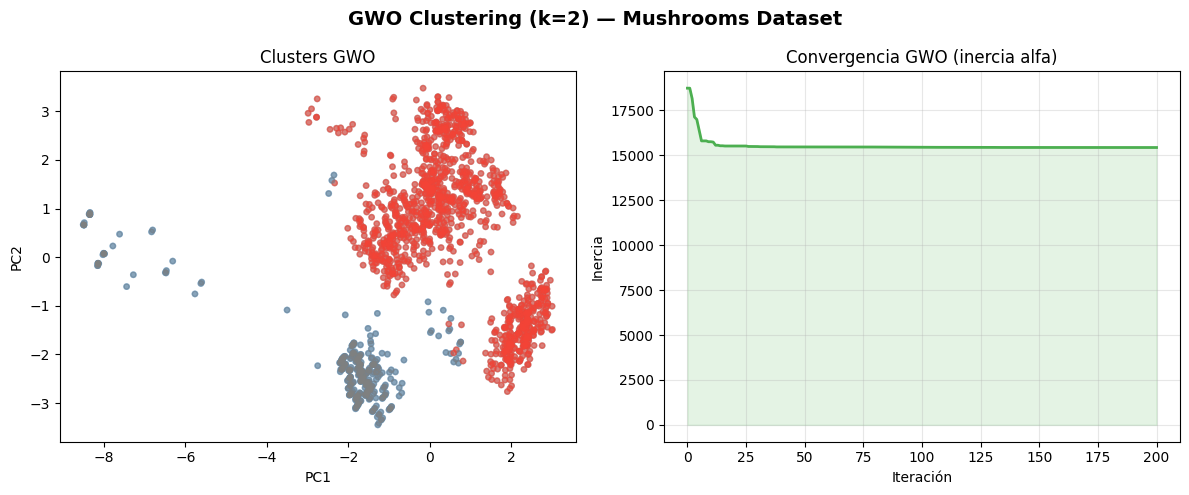


COMPARACIÓN FINAL: PSO vs ABC vs GWO
Métrica                             PSO      ABC      GWO
------------------------------------------------------------
k usado                               2        5        2
Adjusted Rand Index              0.5854   0.2408   0.0939
Silhouette Score                 0.2706   0.5203   0.3465


In [ ]:
# ============================================================
# Ejecutar GWO (k=2 para comparar directo con PSO)
# ============================================================
print('=== GWO Clustering (k=2) ===')
gwo = GWOClustering(k=2, n_wolves=30, max_iter=200, random_state=42)
gwo.fit(X_pca_sample)

ari_gwo = adjusted_rand_score(y_sample, gwo.labels_)
sil_gwo = silhouette_score(X_pca_sample, gwo.labels_)

print(f'\nResultados GWO (k=2):')
print(f'  Inercia final:          {gwo.inertia_:.4f}')
print(f'  Adjusted Rand Index:    {ari_gwo:.4f}')
print(f'  Silhouette Score:       {sil_gwo:.4f}')

for c in range(2):
    mask = gwo.labels_ == c
    n_edible = (y_sample[mask] == 0).sum()
    n_poison = (y_sample[mask] == 1).sum()
    print(f'  Cluster {c}: {mask.sum():5d} puntos | edible={n_edible} | poisonous={n_poison}')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('GWO Clustering (k=2) — Mushrooms Dataset', fontsize=14, fontweight='bold')

colors_gwo = ['#2196F3', '#F44336']
ax = axes[0]
for c in range(2):
    mask = gwo.labels_ == c
    ax.scatter(X_vis[idx_sample, 0], X_vis[idx_sample, 1],
               c=[colors_gwo[c] if m else 'gray' for m in mask],
               alpha=0.5, s=15)
ax.set_title('Clusters GWO')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

ax = axes[1]
ax.plot(gwo.history_, color='#4CAF50', linewidth=2)
ax.fill_between(range(len(gwo.history_)), gwo.history_, alpha=0.15, color='#4CAF50')
ax.set_title('Convergencia GWO (inercia alfa)')
ax.set_xlabel('Iteración'); ax.set_ylabel('Inercia')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gwo_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla comparativa final actualizada
print('\n' + '=' * 60)
print('COMPARACIÓN FINAL: PSO vs ABC vs GWO')
print('=' * 60)
print(f"{'Métrica':<30} {'PSO':>8} {'ABC':>8} {'GWO':>8}")
print('-' * 60)
print(f"{'k usado':<30} {'2':>8} {abc.k_optimal_:>8} {'2':>8}")
print(f"{'Adjusted Rand Index':<30} {ari_pso:>8.4f} {ari_abc:>8.4f} {ari_gwo:>8.4f}")
print(f"{'Silhouette Score':<30} {sil_pso:>8.4f} {sil_abc:>8.4f} {sil_gwo:>8.4f}")
print('=' * 60)

In [ ]:
# ============================================================
# PSO-KModes: PSO con distancia de Hamming
# Trabaja directamente con datos categóricos originales
# ============================================================

# Usar datos originales codificados como enteros (sin escalar ni PCA)
df_int = df.copy()
for col in df_int.columns:
    df_int[col] = LabelEncoder().fit_transform(df_int[col])

X_cat = df_int.drop('class', axis=1).values.astype(int)  # shape (8124, 22)

# Muestra
idx_cat = resample(np.arange(len(X_cat)), n_samples=1500, random_state=42, replace=False)
X_cat_sample = X_cat[idx_cat]
y_cat_sample = y_true[idx_cat]

# Valores únicos por columna (necesario para mutar modas)
col_values = [np.unique(X_cat[:, j]) for j in range(X_cat.shape[1])]

print(f'Datos categóricos: {X_cat_sample.shape}')
print(f'Columnas: {X_cat.shape[1]}')

Datos categóricos: (1500, 22)
Columnas: 22


In [ ]:
class PSOKModes:
    def __init__(self, k, n_particles=50, max_iter=250, random_state=42):
        self.k = k
        self.n_particles = n_particles
        self.max_iter = max_iter
        self.rng = np.random.RandomState(random_state)

    def _hamming(self, a, b):
        return np.sum(a != b, axis=-1)

    def _assign(self, modes, X):
        dists = np.array([self._hamming(X, modes[c]) for c in range(self.k)]).T
        return np.argmin(dists, axis=1)

    def _fitness(self, modes, X):
        labels = self._assign(modes, X)
        if len(np.unique(labels)) < self.k:
            return np.inf, labels
        total = sum(
            self._hamming(X[labels == c], modes[c]).sum()
            for c in range(self.k)
        )
        return total, labels

    def _update_modes(self, labels, X):
        modes = np.zeros((self.k, X.shape[1]), dtype=int)
        for c in range(self.k):
            cluster = X[labels == c]
            if len(cluster) == 0:
                modes[c] = X[self.rng.randint(0, len(X))]
            else:
                for j in range(X.shape[1]):
                    vals, counts = np.unique(cluster[:, j], return_counts=True)
                    modes[c, j] = vals[np.argmax(counts)]
        return modes

    def _init_modes_pp(self, X):
        idx = self.rng.randint(0, len(X))
        modes = [X[idx].copy()]
        for _ in range(1, self.k):
            dists_sq = np.array([
                min(self._hamming(x, m) for m in modes) for x in X
            ], dtype=float)
            probs = dists_sq / (dists_sq.sum() + 1e-9)
            modes.append(X[self.rng.choice(len(X), p=probs)].copy())
        return np.array(modes)

    def fit(self, X, col_values):
        n, d = X.shape

        # ── INICIALIZACIÓN ────────────────────────────────────────
        particles = [self._init_modes_pp(X) for _ in range(self.n_particles)]
        fits, labels_list = [], []
        for p in particles:
            f, lbl = self._fitness(p, X)
            fits.append(f); labels_list.append(lbl)

        pbest = [p.copy() for p in particles]
        pbest_fit = fits.copy()

        gbest_idx = int(np.argmin(pbest_fit))
        gbest = pbest[gbest_idx].copy()
        gbest_fit = pbest_fit[gbest_idx]
        gbest_labels = labels_list[gbest_idx].copy()
        history = [gbest_fit]
        stagnation = 0  # contador de iteraciones sin mejora

        # ── EVOLUCIÓN ─────────────────────────────────────────────
        for iteration in range(self.max_iter):
            w = 0.9 - 0.5 * (iteration / self.max_iter) ** 0.5

            for i in range(self.n_particles):
                new_modes = particles[i].copy()

                for c in range(self.k):
                    for j in range(d):
                        r1, r2 = self.rng.rand(), self.rng.rand()
                        go_pbest = r1 * (1 - w) * (pbest[i][c, j] != new_modes[c, j])
                        go_gbest = r2 * (1 - w) * (gbest[c, j]    != new_modes[c, j])

                        if self.rng.rand() < go_gbest:
                            new_modes[c, j] = gbest[c, j]
                        elif self.rng.rand() < go_pbest:
                            new_modes[c, j] = pbest[i][c, j]
                        elif self.rng.rand() < w:
                            # MUTACIÓN LOCAL en vez de pass
                            new_modes[c, j] = self.rng.choice(col_values[j])

                lbl_new = self._assign(new_modes, X)
                new_modes = self._update_modes(lbl_new, X)
                new_f, new_lbl = self._fitness(new_modes, X)
                particles[i] = new_modes

                if new_f < pbest_fit[i]:
                    pbest[i] = new_modes.copy()
                    pbest_fit[i] = new_f

                if new_f < gbest_fit:
                    gbest = new_modes.copy()
                    gbest_fit = new_f
                    gbest_labels = new_lbl.copy()

            history.append(gbest_fit)

            # REINICIO PARCIAL si hay estancamiento
            if iteration > 30 and history[-1] == history[-2]:
                stagnation += 1
            else:
                stagnation = 0

            if stagnation >= 5:  # 5 iters sin mejora → reiniciar 20%
                n_reset = max(2, int(0.2 * self.n_particles))
                reset_idx = self.rng.choice(self.n_particles, n_reset, replace=False)
                for ri in reset_idx:
                    new_p = self._init_modes_pp(X)
                    particles[ri] = new_p
                    f, lbl = self._fitness(new_p, X)
                    fits[ri] = f
                    if f < pbest_fit[ri]:
                        pbest[ri] = new_p.copy()
                        pbest_fit[ri] = f
                stagnation = 0
                print(f'  [iter {iteration+1}] Reinicio parcial activado')

            if (iteration + 1) % 50 == 0:
                print(f'  Iter {iteration+1:3d}/{self.max_iter} | gbest Hamming = {gbest_fit:.1f} | stagnation={stagnation}')

        # ── FINALIZACIÓN ──────────────────────────────────────────
        self.labels_ = gbest_labels
        self.modes_ = gbest
        self.total_hamming_ = gbest_fit
        self.history_ = history
        return self

In [ ]:
# ============================================================
# Ejecutar PSO-KModes
# ============================================================
print('=== PSO-KModes Clustering (k=2) ===')
psokm = PSOKModes(k=2, n_particles=80, max_iter=300, random_state=42)
psokm.fit(X_cat_sample, col_values)

ari_psokm = adjusted_rand_score(y_cat_sample, psokm.labels_)
sil_psokm = silhouette_score(X_pca_sample, psokm.labels_)  # vis en PCA igual

print(f'\nResultados PSO-KModes (k=2):')
print(f'  Total Hamming:          {psokm.total_hamming_:.1f}')
print(f'  Adjusted Rand Index:    {ari_psokm:.4f}')
print(f'  Silhouette Score:       {sil_psokm:.4f}')

for c in range(2):
    mask = psokm.labels_ == c
    n_edible = (y_cat_sample[mask] == 0).sum()
    n_poison = (y_cat_sample[mask] == 1).sum()
    print(f'  Cluster {c}: {mask.sum():5d} puntos | edible={n_edible} | poisonous={n_poison}')

# Tabla final
print('\n' + '=' * 65)
print('COMPARACIÓN FINAL: PSO vs ABC vs GWO vs PSO-KModes')
print('=' * 65)
print(f"{'Métrica':<30} {'PSO':>8} {'ABC':>8} {'GWO':>8} {'PSO-KM':>8}")
print('-' * 65)
print(f"{'k usado':<30} {'2':>8} {abc.k_optimal_:>8} {'2':>8} {'2':>8}")
print(f"{'Adjusted Rand Index':<30} {ari_pso:>8.4f} {ari_abc:>8.4f} {ari_gwo:>8.4f} {ari_psokm:>8.4f}")
print(f"{'Silhouette Score':<30} {sil_pso:>8.4f} {sil_abc:>8.4f} {sil_gwo:>8.4f} {sil_psokm:>8.4f}")
print('=' * 65)

=== PSO-KModes Clustering (k=2) ===
  [iter 36] Reinicio parcial activado
  [iter 41] Reinicio parcial activado
  [iter 46] Reinicio parcial activado
  Iter  50/300 | gbest Hamming = 11591.0 | stagnation=4
  [iter 51] Reinicio parcial activado
  [iter 56] Reinicio parcial activado
  [iter 61] Reinicio parcial activado
  [iter 66] Reinicio parcial activado
  [iter 71] Reinicio parcial activado
  [iter 76] Reinicio parcial activado
  [iter 81] Reinicio parcial activado
  [iter 86] Reinicio parcial activado
  [iter 91] Reinicio parcial activado
  [iter 96] Reinicio parcial activado
  Iter 100/300 | gbest Hamming = 11591.0 | stagnation=4
  [iter 101] Reinicio parcial activado
  [iter 106] Reinicio parcial activado
  [iter 111] Reinicio parcial activado
  [iter 116] Reinicio parcial activado
  [iter 121] Reinicio parcial activado
  [iter 126] Reinicio parcial activado
  [iter 131] Reinicio parcial activado
  [iter 136] Reinicio parcial activado
  [iter 141] Reinicio parcial activado
  [iter